# 当前实验配置与电网拓扑

（当前实验使用 SimBench `1-LV-rural1--0-sw` 低压农村馈线；3 个家庭热泵 prosumer profile 为 `SFH12`、`SFH18`、`SFH20`，分别接入 bus `12`、`4`、`2`；每个 agent 使用 100 kWh / 50 kW 固定电池；测试窗口为 `2020-04-01` 到 `2020-04-15`；数据来源为 electrical single-family house and heat pump load profiles in Germany, https://www.nature.com/articles/s41597-022-01156-1）


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from matplotlib.lines import Line2D

root = Path.cwd().resolve()
while not (root / "configs" / "experiment_config.py").exists():
    if root == root.parent:
        raise FileNotFoundError("Cannot locate repository root containing configs/experiment_config.py.")
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from configs.experiment_config import ADMM_NOTEBOOK_SPEC, COMPARE_SCHEME_ORDER, MADRL_NOTEBOOK_SPECS
from configs.profiles import compose_experiment_config, summarize_experiment
from envs.grid.deployments import build_agent_deployments
from envs.grid.net_builder import build_simbench_net, zero_static_power_elements
from predictors.mainline_forecast import get_mainline_forecast_controls
from scripts.utils.grid_notebook_workflow import apply_notebook_experiment_settings

warnings.filterwarnings("ignore", category=FutureWarning)

cfg = compose_experiment_config(forecast_type="lstm", data_dir=root / "data", runtime_mode="performance", seed=0)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
apply_notebook_experiment_settings(
    cfg,
    prediction_mode="normal",
    test_start_date=None,
    test_end_date=None,
    agent_profiles=None,
    agent_bus_ids=None,
    load_scale=None,
    pv_scale=None,
    future_horizon=int(forecast_controls["future_horizon"]),
    battery_controls=None,
    forecast_controls=forecast_controls,
    train_year=None,
    test_year=None,
)
summary = summarize_experiment(cfg)
deployments = build_agent_deployments(cfg)
net = zero_static_power_elements(build_simbench_net(cfg.grid.sb_code))


In [2]:
battery = summary["battery"]
config_rows = [
    ("Grid", "SimBench network", summary["grid_sb_code"], f"{len(net.bus)} buses, {len(net.line)} lines, {len(net.trafo)} transformer"),
    ("Grid", "Agent buses", summary["grid_agent_bus_ids"], "One controllable prosumer per bus"),
    ("Data", "Profiles", summary["agent_profiles"], "Single-family household + heat pump profiles"),
    ("Data", "Load / PV scale", f"load={summary['load_scale']}, pv={summary['pv_scale']}", "Canonical current scaling"),
    ("Time", "Training window", f"{summary['train_window_days']} days x {cfg.env.episode_limit} steps/day", f"stride={summary['window_stride_days']} day"),
    ("Time", "Evaluation window", f"{summary['test_start_date']} to {summary['test_end_date']}", f"{summary['test_episode_limit']} steps/day"),
    ("Forecast", "Backend / horizon", f"{summary['forecast']} / {summary['future_horizon']} steps", "15-minute resolution"),
    ("Storage", "Capacity / power", f"{battery['battery_capacity']} kWh / {battery['p_max_kw']} kW", f"C-rate={battery['max_charge_rate']}"),
    ("Storage", "SoC contract", f"init={battery['init_soc']}, range=[{battery['soc_min']}, {battery['soc_max']}], target={battery['soc_target']}", f"efficiency={battery['efficiency']}"),
    ("Learning", "Default algorithm", summary["algo"], f"train_episodes={summary['train_episodes']}, num_envs={summary['num_envs']}"),
    ("Observation", "Feature contract", f"local={summary['local_features']}", f"sequence={summary['sequence_features']}"),
]

config_df = pd.DataFrame(config_rows, columns=["group", "item", "current value", "note"])
display(config_df)

scheme_labels = {
    "global_misocp": "Global MISOCP + Perfect Forecast",
    "local_mpc_perfect": "Local MPC + Perfect Forecast",
    "local_mpc_lstm": "Local MPC + LSTM Forecast",
    ADMM_NOTEBOOK_SPEC["scheme_name"]: ADMM_NOTEBOOK_SPEC["display_label"],
}
scheme_labels.update({spec["scheme_name"]: spec["display_label"] for spec in MADRL_NOTEBOOK_SPECS.values()})
scheme_df = pd.DataFrame(
    [(idx + 1, scheme_name, scheme_labels.get(scheme_name, scheme_name)) for idx, scheme_name in enumerate(COMPARE_SCHEME_ORDER)],
    columns=["order", "scheme_name", "display_label"],
)
display(scheme_df)


,group,item,current value,note
0,Grid,SimBench network,1-LV-rural1--0-sw,"15 buses, 13 lines, 1 transformer"
1,Grid,Agent buses,"[12, 4, 2]",One controllable prosumer per bus
2,Data,Profiles,"[SFH12, SFH18, SFH20]",Single-family household + heat pump profiles
3,Data,Load / PV scale,"load=[20.0, 20.0, 20.0], pv=[1.0, 1.0, 1.0]",Canonical current scaling
4,Time,Training window,7 days x 96 steps/day,stride=1 day
5,Time,Evaluation window,2020-04-01 to 2020-04-15,96 steps/day
6,Forecast,Backend / horizon,lstm / 48 steps,15-minute resolution
7,Storage,Capacity / power,"[100.0, 100.0, 100.0] kWh / [50.0, 50.0, 50.0] kW",C-rate=0.5
8,Storage,SoC contract,"init=0.05, range=[0.05, 0.95], target=0.5",efficiency=0.95
9,Learning,Default algorithm,MADDPG,"train_episodes=1000, num_envs=2"


,order,scheme_name,display_label
0,1,global_misocp,Global MISOCP + Perfect Forecast
1,2,local_mpc_perfect,Local MPC + Perfect Forecast
2,3,local_mpc_lstm,Local MPC + LSTM Forecast
3,4,admm_mpc_lstm,ADMM MPC + LSTM Forecast
4,5,madrl_base,MADRL + No Safety + LSTM Forecast
5,6,madrl_base_safe,MADRL + Safety Penalty + LSTM Forecast
6,7,madrl_projection_safe,MADRL + Safety Projection + LSTM Forecast


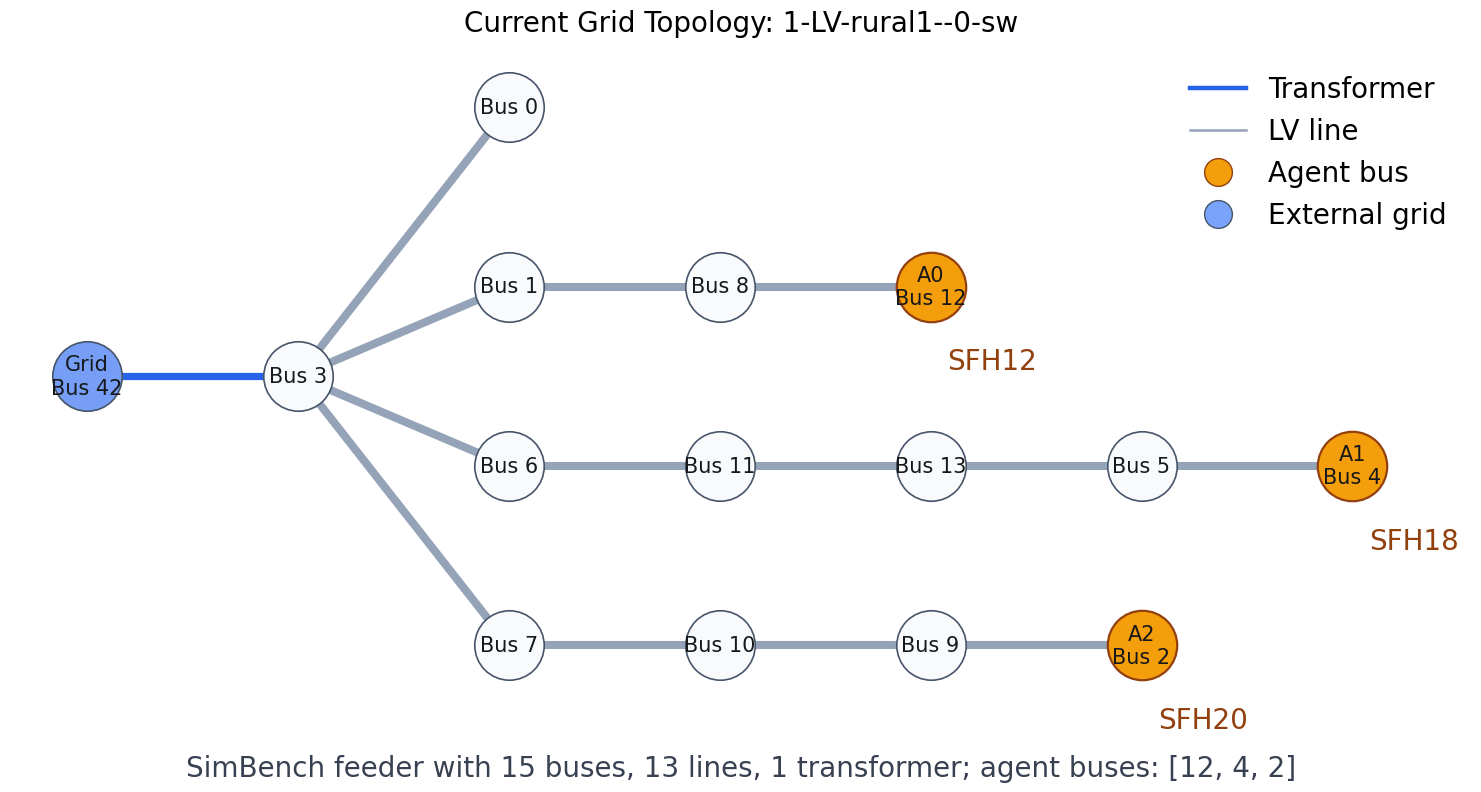

In [18]:
agent_bus_ids = [int(bus_id) for bus_id in cfg.grid.agent_bus_ids]
agent_by_bus = {int(bus_id): idx for idx, bus_id in enumerate(agent_bus_ids)}
profile_by_bus = {int(bus_id): profile for bus_id, profile in zip(agent_bus_ids, cfg.data.agent_profiles, strict=True)}
root_bus = int(net.ext_grid.iloc[0]["bus"])

G = nx.Graph()
for bus_id, row in net.bus.iterrows():
    bus_id = int(bus_id)
    G.add_node(bus_id, label=f"Bus {bus_id}", is_root=bus_id == root_bus, is_agent=bus_id in agent_by_bus, vn_kv=float(row["vn_kv"]))

for _, row in net.line.iterrows():
    G.add_edge(int(row["from_bus"]), int(row["to_bus"]), kind="line", length_km=float(row["length_km"]))

for _, row in net.trafo.iterrows():
    G.add_edge(int(row["hv_bus"]), int(row["lv_bus"]), kind="transformer", sn_mva=float(row["sn_mva"]))

def tree_layout(graph: nx.Graph, root_node: int) -> dict[int, tuple[float, float]]:
    visited: set[int] = set()
    children_by_node: dict[int, list[int]] = {}

    def collect(node: int, parent: int | None = None) -> None:
        visited.add(node)
        children = [neighbor for neighbor in sorted(graph.neighbors(node)) if neighbor != parent and neighbor not in visited]
        children_by_node[node] = children
        for child in children:
            collect(child, node)

    collect(root_node)
    y_cursor = 0
    pos: dict[int, tuple[float, float]] = {}

    def assign(node: int, depth: int) -> float:
        nonlocal y_cursor
        child_ys = [assign(child, depth + 1) for child in children_by_node[node]]
        if child_ys:
            y_value = sum(child_ys) / len(child_ys)
        else:
            y_value = float(-y_cursor)
            y_cursor += 1
        pos[node] = (float(depth), y_value)
        return y_value

    assign(root_node, 0)
    return pos

pos = tree_layout(G, root_bus)
line_edges = [(u, v) for u, v, data in G.edges(data=True) if data["kind"] == "line"]
trafo_edges = [(u, v) for u, v, data in G.edges(data=True) if data["kind"] == "transformer"]
agent_nodes = [bus_id for bus_id in G.nodes if G.nodes[bus_id]["is_agent"]]
root_nodes = [bus_id for bus_id in G.nodes if G.nodes[bus_id]["is_root"]]
plain_nodes = [bus_id for bus_id in G.nodes if bus_id not in set(agent_nodes + root_nodes)]

fig, ax = plt.subplots(figsize=(15, 8))
nx.draw_networkx_edges(G, pos, edgelist=line_edges, width=5.8, edge_color="#94A3B8", ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=trafo_edges, width=5.2, edge_color="#2563EB", ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=plain_nodes, node_color="#F8FAFC", edgecolors="#475569", node_size=2500, linewidths=1.2, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=root_nodes, node_color="#769EF6", edgecolors="#475569", node_size=2500, linewidths=1.2, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=agent_nodes, node_color="#F59E0B", edgecolors="#92400E", node_size=2500, linewidths=1.6, ax=ax)

labels = {}
for bus_id in G.nodes:
    if bus_id == root_bus:
        labels[bus_id] = f"Grid\nBus {bus_id}"
    elif bus_id in agent_by_bus:
        labels[bus_id] = f"A{agent_by_bus[bus_id]}\nBus {bus_id}"
    else:
        labels[bus_id] = f"Bus {bus_id}"

nx.draw_networkx_labels(G, pos, labels=labels, font_size=15, font_color="#171819", ax=ax)
for bus_id in agent_nodes:
    x, y = pos[bus_id]
    ax.text(x + 0.08, y - 0.34, profile_by_bus[bus_id], fontsize=20, color="#92400E", ha="left", va="top")

legend_handles = [
    Line2D([0], [0], color="#2563EB", lw=3.2, label="Transformer"),
    Line2D([0], [0], color="#94A3B8", lw=1.8, label="LV line"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#F59E0B", markeredgecolor="#92400E", markersize=20, label="Agent bus"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#7AA3FC", markeredgecolor="#475569", markersize=20, label="External grid"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False,fontsize=20)
ax.set_title(f"Current Grid Topology: {cfg.grid.sb_code}", fontsize=20, pad=14)
ax.text(
    0.5,
    -0.08,
    f"SimBench feeder with {len(net.bus)} buses, {len(net.line)} lines, {len(net.trafo)} transformer; agent buses: {agent_bus_ids}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=20,
    color="#374151",
)
ax.set_axis_off()
fig.tight_layout()
plt.show()
